In [ ]:
# Basic libraries
import pandas as pd
import numpy as np

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

# For plotting
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.listdir('/content/drive/MyDrive')

['glove.6B.50d.txt',
 'Resume (1).gdoc',
 'Resume.gdoc',
 'Rakesh Koyyalamudi  817189.pdf',
 'Colab Notebooks',
 "rakesh's Resume.docx",
 'Classroom',
 'AWS_Academy_Graduate___AWS_Academy_Cloud_Foundations_Badge20230127-32-1627klm.pdf',
 "rakesh's new Resume.pdf",
 'IMG_20231026_092741__01.jpg',
 'Zeotap Intern Assignment (1).pdf',
 'GTE Interview Questions.docx',
 'Rakesh_Koyyalamudi_Resume (1).pdf',
 'Rakesh_Koyyalamudi_Resume.pdf',
 'Rakesh_Koyyalamudi_Resume_S.pdf',
 'Passport_allpages.pdf',
 'PassportSizephoto.jpg',
 'Dr. Kusuma Tiruveedhi_Resume_KC (1).pdf',
 'Visa Application form.docx',
 'Dr. Kusuma Tiruveedhi_Resume_KC (1).gdoc',
 'timetable-225556957 (1).gdoc',
 'timetable-225556957.gdoc',
 'Untitled document.gdoc',
 'gene',
 'obesity',
 'video1995977942.mp4',
 'Screen Recording 2025-08-29 165434.mp4',
 '225404893_Assessment-2.pdf',
 'bank+marketing',
 'SIT-720-6.1-PT Code.ipynb',
 'Part1Task2.mp4',
 'Part2Task2.mp4',
 'Part1Task1.mp4',
 'traffic_sign_dataset',
 '9.1D AI Safe

In [ ]:
dataset_path = "/content/drive/MyDrive/News_Category_Dataset_v3.json"

df = pd.read_json(dataset_path, lines=True)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns)

df.head()

Dataset shape: (209527, 6)

Columns:
Index(['link', 'headline', 'category', 'short_description', 'authors', 'date'], dtype='object')


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [ ]:
# Creating a copy of the original dataset
data = df.copy()

# Converting date column to datetime format
data['date'] = pd.to_datetime(data['date'])

# Creating year column from date
data['year'] = data['date'].dt.year

# Filling missing text values with empty string
data['headline'] = data['headline'].fillna('')
data['short_description'] = data['short_description'].fillna('')

# Combining headline and short description into one text column
data['text'] = data['headline'] + ' ' + data['short_description']

# Removes rows where text is empty
data = data[data['text'].str.strip() != '']

# Keeps only the columns needed for this experiment
data = data[['text', 'category', 'date', 'year']]

print("Cleaned dataset shape:", data.shape)
print("\nColumns after cleaning:")
print(data.columns)

print("\nYear range:")
print(data['year'].min(), "to", data['year'].max())

data.head()

Cleaned dataset shape: (209522, 4)

Columns after cleaning:
Index(['text', 'category', 'date', 'year'], dtype='object')

Year range:
2012 to 2022


,text,category,date,year
0,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,2022-09-23,2022
1,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,2022-09-23,2022
2,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,2022-09-23,2022
3,The Funniest Tweets From Parents This Week (Se...,PARENTING,2022-09-23,2022
4,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,2022-09-22,2022


In [ ]:
print("Number of categories:", data['category'].nunique())

print("\nTop 15 categories:")
print(data['category'].value_counts().head(15))

print("\nNumber of articles by year:")
print(data['year'].value_counts().sort_index())

Number of categories: 42

Top 15 categories:
category
POLITICS          35601
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6346
FOOD & DRINK       6340
BUSINESS           5991
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
Name: count, dtype: int64

Number of articles by year:
year
2012    31355
2013    34583
2014    32338
2015    32002
2016    32098
2017    29889
2018     9734
2019     2005
2020     2054
2021     2066
2022     1398
Name: count, dtype: int64


In [ ]:
data['year'].value_counts().sort_index()

,count
year,
2012,31355
2013,34583
2014,32338
2015,32002
2016,32098
2017,29889
2018,9734
2019,2005
2020,2054


In [ ]:
print("Top 15 categories:")
print(data['category'].value_counts().head(15))

Top 15 categories:
category
POLITICS          35601
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6346
FOOD & DRINK       6340
BUSINESS           5991
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
Name: count, dtype: int64


In [ ]:
# Defines old and newer periods
old_data = data[(data['year'] >= 2012) & (data['year'] <= 2017)]
future_data = data[(data['year'] >= 2019) & (data['year'] <= 2022)]

print("Old period shape:", old_data.shape)
print("Future period shape:", future_data.shape)

# Counts categories in old and future periods
old_counts = old_data['category'].value_counts()
future_counts = future_data['category'].value_counts()

# Combining counts into one table
category_period_counts = pd.DataFrame({
    'old_2012_2017': old_counts,
    'future_2019_2022': future_counts
}).fillna(0).astype(int)

# Adding total count
category_period_counts['total'] = category_period_counts['old_2012_2017'] + category_period_counts['future_2019_2022']

# Sorting by future period because future test data is smaller
category_period_counts = category_period_counts.sort_values(by='future_2019_2022', ascending=False)

category_period_counts.head(20)

Old period shape: (192265, 4)
Future period shape: (7523, 4)


,old_2012_2017,future_2019_2022,total
category,,,
POLITICS,29671,2531,32202
U.S. NEWS,0,1208,1208
ENTERTAINMENT,14338,1162,15500
WORLD NEWS,1612,895,2507
SPORTS,4520,173,4693
STYLE & BEAUTY,9649,156,9805
COMEDY,4732,155,4887
CRIME,3231,131,3362
HOME & LIVING,4195,121,4316


In [ ]:
category_period_counts.head(20)

,old_2012_2017,future_2019_2022,total
category,,,
POLITICS,29671,2531,32202
U.S. NEWS,0,1208,1208
ENTERTAINMENT,14338,1162,15500
WORLD NEWS,1612,895,2507
SPORTS,4520,173,4693
STYLE & BEAUTY,9649,156,9805
COMEDY,4732,155,4887
CRIME,3231,131,3362
HOME & LIVING,4195,121,4316


In [ ]:
# Final categories selected for the experiment
selected_categories = [
    'POLITICS',
    'ENTERTAINMENT',
    'WORLD NEWS',
    'SPORTS',
    'STYLE & BEAUTY',
    'COMEDY',
    'CRIME',
    'HOME & LIVING',
    'WELLNESS',
    'FOOD & DRINK',
    'PARENTING',
    'ENVIRONMENT'
]

# Keeps only selected categories
selected_data = data[data['category'].isin(selected_categories)].copy()

# Removing 2018 for this first experiment
# 2018 is left out so that the comparison is clearly older years vs newer years
selected_data = selected_data[selected_data['year'] != 2018]

print("Selected dataset shape:", selected_data.shape)

print("\nSelected category counts:")
print(selected_data['category'].value_counts())

print("\nSelected year counts:")
print(selected_data['year'].value_counts().sort_index())

Selected dataset shape: (111765, 4)

Selected category counts:
category
POLITICS          32202
WELLNESS          17942
ENTERTAINMENT     15500
STYLE & BEAUTY     9805
PARENTING          8788
FOOD & DRINK       6339
COMEDY             4887
SPORTS             4693
HOME & LIVING      4316
CRIME              3362
WORLD NEWS         2507
ENVIRONMENT        1424
Name: count, dtype: int64

Selected year counts:
year
2012    21019
2013    24099
2014    13873
2015    12954
2016    16631
2017    17425
2019     1310
2020     1718
2021     1673
2022     1063
Name: count, dtype: int64


In [ ]:
# Creating old training data and future testing data
temporal_train = selected_data[(selected_data['year'] >= 2012) & (selected_data['year'] <= 2017)]
temporal_test = selected_data[(selected_data['year'] >= 2019) & (selected_data['year'] <= 2022)]

print("Temporal train shape:", temporal_train.shape)
print("Temporal test shape:", temporal_test.shape)

print("\nTemporal train category counts:")
print(temporal_train['category'].value_counts())

print("\nTemporal test category counts:")
print(temporal_test['category'].value_counts())

Temporal train shape: (106001, 4)
Temporal test shape: (5764, 4)

Temporal train category counts:
category
POLITICS          29671
WELLNESS          17827
ENTERTAINMENT     14338
STYLE & BEAUTY     9649
PARENTING          8677
FOOD & DRINK       6226
COMEDY             4732
SPORTS             4520
HOME & LIVING      4195
CRIME              3231
WORLD NEWS         1612
ENVIRONMENT        1323
Name: count, dtype: int64

Temporal test category counts:
category
POLITICS          2531
ENTERTAINMENT     1162
WORLD NEWS         895
SPORTS             173
STYLE & BEAUTY     156
COMEDY             155
CRIME              131
HOME & LIVING      121
WELLNESS           115
FOOD & DRINK       113
PARENTING          111
ENVIRONMENT        101
Name: count, dtype: int64


In [ ]:
from sklearn.pipeline import Pipeline

# Preparing features and labels for random split
X = selected_data['text']
y = selected_data['category']

# Random train-test split with stratification to keep category proportions similar
X_train_random, X_test_random, y_train_random, y_test_random = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Random train size:", X_train_random.shape[0])
print("Random test size:", X_test_random.shape[0])

# Building TF-IDF + Logistic Regression pipeline
random_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        max_features=50000,
        ngram_range=(1, 2),
        min_df=2
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

# Trains the model
random_model.fit(X_train_random, y_train_random)

# Predicting on random test data
y_pred_random = random_model.predict(X_test_random)

# Evaluation
random_accuracy = accuracy_score(y_test_random, y_pred_random)
random_macro_f1 = f1_score(y_test_random, y_pred_random, average='macro')

print("Random Split Results")
print("Accuracy:", round(random_accuracy, 4))
print("Macro-F1:", round(random_macro_f1, 4))

Random train size: 89412
Random test size: 22353
Random Split Results
Accuracy: 0.7976
Macro-F1: 0.7419


In [ ]:
print("Classification Report for Random Split:")
print(classification_report(y_test_random, y_pred_random))

Classification Report for Random Split:
                precision    recall  f1-score   support

        COMEDY       0.48      0.56      0.52       977
         CRIME       0.56      0.82      0.67       672
 ENTERTAINMENT       0.82      0.75      0.78      3100
   ENVIRONMENT       0.46      0.71      0.56       285
  FOOD & DRINK       0.80      0.84      0.82      1268
 HOME & LIVING       0.77      0.84      0.81       863
     PARENTING       0.75      0.80      0.77      1758
      POLITICS       0.93      0.80      0.86      6440
        SPORTS       0.76      0.84      0.80       939
STYLE & BEAUTY       0.87      0.86      0.87      1961
      WELLNESS       0.84      0.83      0.83      3588
    WORLD NEWS       0.51      0.76      0.61       502

      accuracy                           0.80     22353
     macro avg       0.71      0.79      0.74     22353
  weighted avg       0.81      0.80      0.80     22353



In [ ]:
# Prepare temporal train and test data
X_train_temporal = temporal_train['text']
y_train_temporal = temporal_train['category']

X_test_temporal = temporal_test['text']
y_test_temporal = temporal_test['category']

print("Temporal train size:", X_train_temporal.shape[0])
print("Temporal test size:", X_test_temporal.shape[0])

# Builds the same TF-IDF + Logistic Regression pipeline
temporal_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        max_features=50000,
        ngram_range=(1, 2),
        min_df=2
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

# Training only on older news
temporal_model.fit(X_train_temporal, y_train_temporal)

# Testing on newer news
y_pred_temporal = temporal_model.predict(X_test_temporal)

# Evaluation
temporal_accuracy = accuracy_score(y_test_temporal, y_pred_temporal)
temporal_macro_f1 = f1_score(y_test_temporal, y_pred_temporal, average='macro')

print("Temporal Split Results")
print("Accuracy:", round(temporal_accuracy, 4))
print("Macro-F1:", round(temporal_macro_f1, 4))


Temporal train size: 106001
Temporal test size: 5764
Temporal Split Results
Accuracy: 0.7354
Macro-F1: 0.6078


In [ ]:
print("Classification Report for Temporal Split:")
print(classification_report(y_test_temporal, y_pred_temporal))

Classification Report for Temporal Split:
                precision    recall  f1-score   support

        COMEDY       0.33      0.88      0.48       155
         CRIME       0.34      0.87      0.49       131
 ENTERTAINMENT       0.82      0.63      0.71      1162
   ENVIRONMENT       0.38      0.51      0.44       101
  FOOD & DRINK       0.82      0.75      0.78       113
 HOME & LIVING       0.45      0.28      0.35       121
     PARENTING       0.53      0.80      0.64       111
      POLITICS       0.92      0.82      0.87      2531
        SPORTS       0.55      0.92      0.69       173
STYLE & BEAUTY       0.60      0.63      0.61       156
      WELLNESS       0.38      0.79      0.51       115
    WORLD NEWS       0.83      0.64      0.72       895

      accuracy                           0.74      5764
     macro avg       0.58      0.71      0.61      5764
  weighted avg       0.80      0.74      0.75      5764



In [ ]:
# Calculating performance gaps
accuracy_gap = random_accuracy - temporal_accuracy
macro_f1_gap = random_macro_f1 - temporal_macro_f1

# Creating result table
results = pd.DataFrame({
    'Evaluation Setting': ['Random split', 'Temporal split'],
    'Training Data': ['Mixed years', '2012-2017'],
    'Testing Data': ['Mixed years', '2019-2022'],
    'Accuracy': [random_accuracy, temporal_accuracy],
    'Macro-F1': [random_macro_f1, temporal_macro_f1]
})

# Rounding the values for clear display
results_display = results.copy()
results_display['Accuracy'] = results_display['Accuracy'].round(4)
results_display['Macro-F1'] = results_display['Macro-F1'].round(4)

print("Final Results Table:")
print(results_display)

print("\nTemporal Generalisation Gap:")
print("Accuracy gap:", round(accuracy_gap, 4))
print("Macro-F1 gap:", round(macro_f1_gap, 4))

Final Results Table:
  Evaluation Setting Training Data Testing Data  Accuracy  Macro-F1
0       Random split   Mixed years  Mixed years    0.7976    0.7419
1     Temporal split     2012-2017    2019-2022    0.7354    0.6078

Temporal Generalisation Gap:
Accuracy gap: 0.0621
Macro-F1 gap: 0.1342


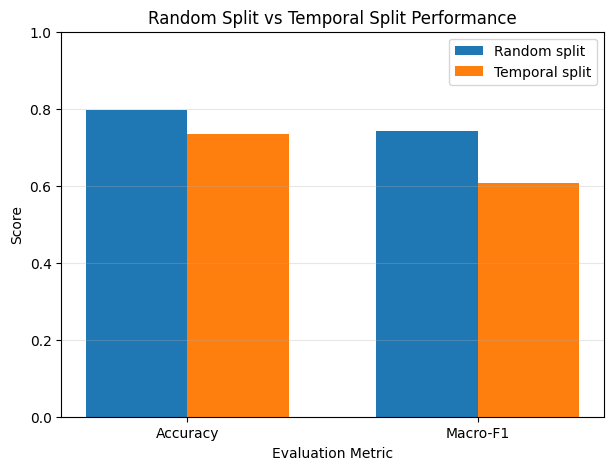

In [ ]:
# Creates a bar chart for Accuracy and Macro-F1 comparison
metrics = ['Accuracy', 'Macro-F1']
random_scores = [random_accuracy, random_macro_f1]
temporal_scores = [temporal_accuracy, temporal_macro_f1]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(7, 5))
plt.bar(x - width/2, random_scores, width, label='Random split')
plt.bar(x + width/2, temporal_scores, width, label='Temporal split')

plt.xlabel('Evaluation Metric')
plt.ylabel('Score')
plt.title('Random Split vs Temporal Split Performance')
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Save figure
plt.savefig('temporal_drift_results.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
from google.colab import files
files.download('temporal_drift_results.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Restoring required variables after Colab runtime reset

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report

dataset_path = "/content/drive/MyDrive/News_Category_Dataset_v3.json"

# Load dataset
df = pd.read_json(dataset_path, lines=True)

# Clean and prepare dataset
data = df.copy()
data['date'] = pd.to_datetime(data['date'])
data['year'] = data['date'].dt.year

data['headline'] = data['headline'].fillna('')
data['short_description'] = data['short_description'].fillna('')

data['text'] = data['headline'] + ' ' + data['short_description']
data = data[data['text'].str.strip() != '']

data = data[['text', 'category', 'date', 'year']]

# Same 12 categories used in Task 2.2D
selected_categories = [
    'POLITICS',
    'ENTERTAINMENT',
    'WORLD NEWS',
    'SPORTS',
    'STYLE & BEAUTY',
    'COMEDY',
    'CRIME',
    'HOME & LIVING',
    'WELLNESS',
    'FOOD & DRINK',
    'PARENTING',
    'ENVIRONMENT'
]

print("Dataset restored successfully")
print("Cleaned data shape:", data.shape)
print("Year range:", data['year'].min(), "to", data['year'].max())

Mounted at /content/drive
Dataset restored successfully
Cleaned data shape: (209522, 4)
Year range: 2012 to 2022


In [ ]:
hd_data = data[data['category'].isin(selected_categories)].copy()

old_train_hd = hd_data[(hd_data['year'] >= 2012) & (hd_data['year'] <= 2017)]
adaptation_2018_hd = hd_data[hd_data['year'] == 2018]
future_test_hd = hd_data[(hd_data['year'] >= 2019) & (hd_data['year'] <= 2022)]

print("Old training data shape:", old_train_hd.shape)
print("2018 adaptation data shape:", adaptation_2018_hd.shape)
print("Future test data shape:", future_test_hd.shape)

print("\n2018 adaptation category counts:")
print(adaptation_2018_hd['category'].value_counts())

print("\nFuture test category counts:")
print(future_test_hd['category'].value_counts())

Old training data shape: (106001, 4)
2018 adaptation data shape: (7190, 4)
Future test data shape: (5764, 4)

2018 adaptation category counts:
category
POLITICS          3399
ENTERTAINMENT     1862
WORLD NEWS         792
COMEDY             513
SPORTS             384
CRIME              200
ENVIRONMENT         20
STYLE & BEAUTY       9
HOME & LIVING        4
WELLNESS             3
PARENTING            3
FOOD & DRINK         1
Name: count, dtype: int64

Future test category counts:
category
POLITICS          2531
ENTERTAINMENT     1162
WORLD NEWS         895
SPORTS             173
STYLE & BEAUTY     156
COMEDY             155
CRIME              131
HOME & LIVING      121
WELLNESS           115
FOOD & DRINK       113
PARENTING          111
ENVIRONMENT        101
Name: count, dtype: int64


In [ ]:
# HD Baseline 1: Older-only temporal baseline

X_train_old = old_train_hd['text']
y_train_old = old_train_hd['category']

X_test_future = future_test_hd['text']
y_test_future = future_test_hd['category']

old_only_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        max_features=50000,
        ngram_range=(1, 2),
        min_df=2
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

# Train on 2012-2017
old_only_model.fit(X_train_old, y_train_old)

# Test on 2019-2022
y_pred_old_only = old_only_model.predict(X_test_future)

# Evaluation
old_only_accuracy = accuracy_score(y_test_future, y_pred_old_only)
old_only_macro_f1 = f1_score(y_test_future, y_pred_old_only, average='macro')

print("HD Baseline 1: Older-only Temporal Baseline")
print("Train period: 2012-2017")
print("Test period: 2019-2022")
print("Accuracy:", round(old_only_accuracy, 4))
print("Macro-F1:", round(old_only_macro_f1, 4))

HD Baseline 1: Older-only Temporal Baseline
Train period: 2012-2017
Test period: 2019-2022
Accuracy: 0.7354
Macro-F1: 0.6078


In [ ]:
print("Classification Report: Older-only Baseline")
print(classification_report(y_test_future, y_pred_old_only))

Classification Report: Older-only Baseline
                precision    recall  f1-score   support

        COMEDY       0.33      0.88      0.48       155
         CRIME       0.34      0.87      0.49       131
 ENTERTAINMENT       0.82      0.63      0.71      1162
   ENVIRONMENT       0.38      0.51      0.44       101
  FOOD & DRINK       0.82      0.75      0.78       113
 HOME & LIVING       0.45      0.28      0.35       121
     PARENTING       0.53      0.80      0.64       111
      POLITICS       0.92      0.82      0.87      2531
        SPORTS       0.55      0.92      0.69       173
STYLE & BEAUTY       0.60      0.63      0.61       156
      WELLNESS       0.38      0.79      0.51       115
    WORLD NEWS       0.83      0.64      0.72       895

      accuracy                           0.74      5764
     macro avg       0.58      0.71      0.61      5764
  weighted avg       0.80      0.74      0.75      5764



In [ ]:
# SIT770 Task 2.3HD - Proposed Solution for Temporal Drift

"""The previous experiment showed that the TF-IDF with Logistic Regression model performs worse when trained on older news articles and tested on newer news articles. This suggests that temporal drift affects news category classification.

For the High Distinction task, I extend the previous experiment by testing whether a simple recency-aware adaptation method can reduce this temporal performance gap. Instead of using only 2012–2017 as training data, I use 2018 as a recent adaptation period before testing on 2019–2022.

The main idea is that recent labelled news articles may contain language patterns, topics, and named entities that are closer to the future test data. Therefore, giving more importance to recent data may help the classifier generalise better to newer articles.
"""

'The previous experiment showed that the TF-IDF with Logistic Regression model performs worse when trained on older news articles and tested on newer news articles. This suggests that temporal drift affects news category classification.\n\nFor the High Distinction task, I extend the previous experiment by testing whether a simple recency-aware adaptation method can reduce this temporal performance gap. Instead of using only 2012–2017 as training data, I use 2018 as a recent adaptation period before testing on 2019–2022.\n\nThe main idea is that recent labelled news articles may contain language patterns, topics, and named entities that are closer to the future test data. Therefore, giving more importance to recent data may help the classifier generalise better to newer articles.\n'

In [ ]:
# HD Baseline 2: Simple update baseline
# Training on 2012-2018 and test on 2019-2022

simple_update_train = hd_data[(hd_data['year'] >= 2012) & (hd_data['year'] <= 2018)]

X_train_update = simple_update_train['text']
y_train_update = simple_update_train['category']

X_test_future = future_test_hd['text']
y_test_future = future_test_hd['category']

print("Simple update train size:", X_train_update.shape[0])
print("Future test size:", X_test_future.shape[0])

simple_update_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        max_features=50000,
        ngram_range=(1, 2),
        min_df=2
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

# Training on 2012-2018
simple_update_model.fit(X_train_update, y_train_update)

# Testing on 2019-2022
y_pred_update = simple_update_model.predict(X_test_future)

# Evaluation
simple_update_accuracy = accuracy_score(y_test_future, y_pred_update)
simple_update_macro_f1 = f1_score(y_test_future, y_pred_update, average='macro')

print("HD Baseline 2: Simple Update Baseline")
print("Train period: 2012-2018")
print("Test period: 2019-2022")
print("Accuracy:", round(simple_update_accuracy, 4))
print("Macro-F1:", round(simple_update_macro_f1, 4))

Simple update train size: 113191
Future test size: 5764
HD Baseline 2: Simple Update Baseline
Train period: 2012-2018
Test period: 2019-2022
Accuracy: 0.751
Macro-F1: 0.6224


In [ ]:
print("Classification Report: Simple Update Baseline")
print(classification_report(y_test_future, y_pred_update))

Classification Report: Simple Update Baseline
                precision    recall  f1-score   support

        COMEDY       0.34      0.88      0.49       155
         CRIME       0.37      0.86      0.51       131
 ENTERTAINMENT       0.83      0.65      0.73      1162
   ENVIRONMENT       0.41      0.50      0.46       101
  FOOD & DRINK       0.83      0.75      0.79       113
 HOME & LIVING       0.47      0.29      0.36       121
     PARENTING       0.54      0.81      0.65       111
      POLITICS       0.94      0.81      0.87      2531
        SPORTS       0.57      0.92      0.70       173
STYLE & BEAUTY       0.61      0.62      0.61       156
      WELLNESS       0.40      0.80      0.53       115
    WORLD NEWS       0.82      0.74      0.77       895

      accuracy                           0.75      5764
     macro avg       0.59      0.72      0.62      5764
  weighted avg       0.81      0.75      0.77      5764



In [ ]:
## Proposed Method: Recency-Aware Weighted Training
"""
The proposed method uses the same 2012 to 2018 training period as the simple update baseline, but it gives higher sample weight to the 2018 examples. The reason is that 2018 is closer to the future test period, so its language patterns, topics, and named entities may be more useful for classifying articles from 2019 to 2022.

In this experiment, examples from 2012 to 2017 receive weight 1, while examples from 2018 receive weight 3. The classifier still uses class-weighted Logistic Regression, so the method considers both category imbalance and temporal recency.
"""

In [ ]:
# Proposed Method: Recency-aware weighted training
# Train on 2012-2018, but giv higher weight to 2018 examples

recency_train = hd_data[(hd_data['year'] >= 2012) & (hd_data['year'] <= 2018)].copy()

X_train_recency = recency_train['text']
y_train_recency = recency_train['category']

X_test_future = future_test_hd['text']
y_test_future = future_test_hd['category']

# Assigning sample weights
# Older examples get weight 1, recent 2018 examples get weight 3
sample_weights = np.where(recency_train['year'] == 2018, 3.0, 1.0)

print("Recency-aware train size:", X_train_recency.shape[0])
print("Future test size:", X_test_future.shape[0])
print("Number of 2018 examples:", (recency_train['year'] == 2018).sum())
print("Number of 2012-2017 examples:", (recency_train['year'] < 2018).sum())

recency_weighted_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        max_features=50000,
        ngram_range=(1, 2),
        min_df=2
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

# Training with sample weights
recency_weighted_model.fit(
    X_train_recency,
    y_train_recency,
    clf__sample_weight=sample_weights
)

# Predicting on future test data
y_pred_recency = recency_weighted_model.predict(X_test_future)

# Evaluation
recency_accuracy = accuracy_score(y_test_future, y_pred_recency)
recency_macro_f1 = f1_score(y_test_future, y_pred_recency, average='macro')

print("Proposed Method: Recency-Aware Weighted Training")
print("Train period: 2012-2018")
print("2018 sample weight: 3.0")
print("Test period: 2019-2022")
print("Accuracy:", round(recency_accuracy, 4))
print("Macro-F1:", round(recency_macro_f1, 4))

Recency-aware train size: 113191
Future test size: 5764
Number of 2018 examples: 7190
Number of 2012-2017 examples: 106001
Proposed Method: Recency-Aware Weighted Training
Train period: 2012-2018
2018 sample weight: 3.0
Test period: 2019-2022
Accuracy: 0.7639
Macro-F1: 0.6339


In [ ]:
print("Classification Report: Recency-Aware Weighted Training")
print(classification_report(y_test_future, y_pred_recency))

Classification Report: Recency-Aware Weighted Training
                precision    recall  f1-score   support

        COMEDY       0.35      0.88      0.50       155
         CRIME       0.40      0.86      0.54       131
 ENTERTAINMENT       0.83      0.67      0.74      1162
   ENVIRONMENT       0.43      0.49      0.46       101
  FOOD & DRINK       0.83      0.75      0.79       113
 HOME & LIVING       0.47      0.28      0.35       121
     PARENTING       0.58      0.82      0.68       111
      POLITICS       0.94      0.83      0.88      2531
        SPORTS       0.57      0.92      0.71       173
STYLE & BEAUTY       0.64      0.61      0.62       156
      WELLNESS       0.43      0.77      0.55       115
    WORLD NEWS       0.81      0.76      0.78       895

      accuracy                           0.76      5764
     macro avg       0.61      0.72      0.63      5764
  weighted avg       0.81      0.76      0.78      5764



In [ ]:
## Final Comparison of HD Methods
"""
In this step, I compare all three methods in one table. This makes it easier to check whether the proposed recency-aware weighted method improves future news classification compared with the older-only baseline and the simple update baseline.
"""

# Final HD results comparison table

hd_results = pd.DataFrame({
    'Method': [
        'Older-only baseline',
        'Simple update baseline',
        'Proposed recency-aware method'
    ],
    'Training Data': [
        '2012-2017',
        '2012-2018',
        '2012-2018 with 2018 weight = 3'
    ],
    'Test Data': [
        '2019-2022',
        '2019-2022',
        '2019-2022'
    ],
    'Accuracy': [
        old_only_accuracy,
        simple_update_accuracy,
        recency_accuracy
    ],
    'Macro-F1': [
        old_only_macro_f1,
        simple_update_macro_f1,
        recency_macro_f1
    ]
})

# Calculating improvement over older-only baseline
hd_results['Accuracy Improvement over Older-only'] = hd_results['Accuracy'] - old_only_accuracy
hd_results['Macro-F1 Improvement over Older-only'] = hd_results['Macro-F1'] - old_only_macro_f1

# Displaying rounded table
hd_results_display = hd_results.copy()
for col in ['Accuracy', 'Macro-F1', 'Accuracy Improvement over Older-only', 'Macro-F1 Improvement over Older-only']:
    hd_results_display[col] = hd_results_display[col].round(4)

hd_results_display

,Method,Training Data,Test Data,Accuracy,Macro-F1,Accuracy Improvement over Older-only,Macro-F1 Improvement over Older-only
0,Older-only baseline,2012-2017,2019-2022,0.7354,0.6078,0.0000,0.0000
1,Simple update baseline,2012-2018,2019-2022,0.7510,0.6224,0.0156,0.0146
2,Proposed recency-aware method,2012-2018 with 2018 weight = 3,2019-2022,0.7639,0.6339,0.0285,0.0261


In [ ]:
hd_results_display.to_csv('hd_temporal_drift_results.csv', index=False)

print("HD results table saved as hd_temporal_drift_results.csv")

HD results table saved as hd_temporal_drift_results.csv


In [ ]:
from google.colab import files
files.download('hd_temporal_drift_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

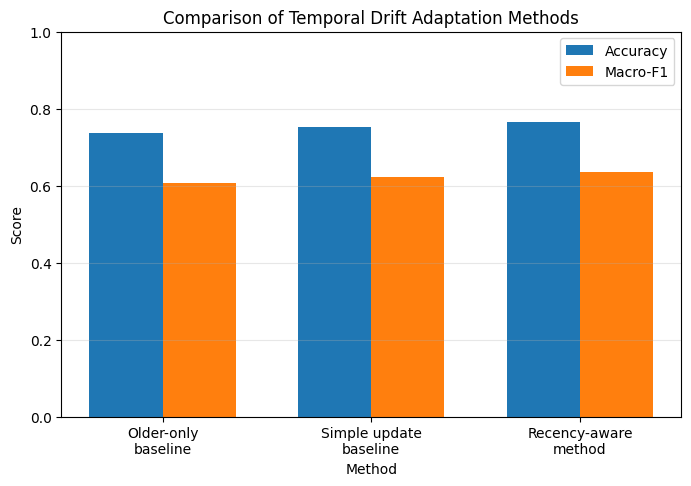

In [ ]:
# Creating HD comparison graph

methods = [
    'Older-only\nbaseline',
    'Simple update\nbaseline',
    'Recency-aware\nmethod'
]

accuracy_scores = [
    old_only_accuracy,
    simple_update_accuracy,
    recency_accuracy
]

macro_f1_scores = [
    old_only_macro_f1,
    simple_update_macro_f1,
    recency_macro_f1
]

x = np.arange(len(methods))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, accuracy_scores, width, label='Accuracy')
plt.bar(x + width/2, macro_f1_scores, width, label='Macro-F1')

plt.xlabel('Method')
plt.ylabel('Score')
plt.title('Comparison of Temporal Drift Adaptation Methods')
plt.xticks(x, methods)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.savefig('hd_temporal_drift_methods.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import files
files.download('hd_temporal_drift_methods.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

# Get per-category F1 scores for older-only baseline
old_precision, old_recall, old_f1, old_support = precision_recall_fscore_support(
    y_test_future,
    y_pred_old_only,
    labels=selected_categories,
    zero_division=0
)

# Get per-category F1 scores for proposed recency-aware method
rec_precision, rec_recall, rec_f1, rec_support = precision_recall_fscore_support(
    y_test_future,
    y_pred_recency,
    labels=selected_categories,
    zero_division=0
)

# Creates per-category comparison table
category_error_analysis = pd.DataFrame({
    'Category': selected_categories,
    'Support': old_support,
    'Older-only F1': old_f1,
    'Recency-aware F1': rec_f1,
    'F1 Change': rec_f1 - old_f1
})

category_error_analysis_display = category_error_analysis.copy()
for col in ['Older-only F1', 'Recency-aware F1', 'F1 Change']:
    category_error_analysis_display[col] = category_error_analysis_display[col].round(4)

category_error_analysis_display = category_error_analysis_display.sort_values(
    by='F1 Change',
    ascending=False
)

category_error_analysis_display

,Category,Support,Older-only F1,Recency-aware F1,F1 Change
2,WORLD NEWS,895,0.7250,0.7820,0.0570
6,CRIME,131,0.4935,0.5420,0.0485
10,PARENTING,111,0.6357,0.6816,0.0459
8,WELLNESS,115,0.5098,0.5494,0.0396
1,ENTERTAINMENT,1162,0.7132,0.7429,0.0297
5,COMEDY,155,0.4774,0.5009,0.0236
11,ENVIRONMENT,101,0.4351,0.4558,0.0207
3,SPORTS,173,0.6913,0.7080,0.0167
0,POLITICS,2531,0.8670,0.8794,0.0124
4,STYLE & BEAUTY,156,0.6149,0.6250,0.0101


In [ ]:
category_error_analysis_display.to_csv('hd_per_category_error_analysis.csv', index=False)

from google.colab import files
files.download('hd_per_category_error_analysis.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
category_error_analysis_display

,Category,Support,Older-only F1,Recency-aware F1,F1 Change
2,WORLD NEWS,895,0.7250,0.7820,0.0570
6,CRIME,131,0.4935,0.5420,0.0485
10,PARENTING,111,0.6357,0.6816,0.0459
8,WELLNESS,115,0.5098,0.5494,0.0396
1,ENTERTAINMENT,1162,0.7132,0.7429,0.0297
5,COMEDY,155,0.4774,0.5009,0.0236
11,ENVIRONMENT,101,0.4351,0.4558,0.0207
3,SPORTS,173,0.6913,0.7080,0.0167
0,POLITICS,2531,0.8670,0.8794,0.0124
4,STYLE & BEAUTY,156,0.6149,0.6250,0.0101


In [ ]:
"""## Error Analysis Summary

The per-category analysis shows that the recency-aware weighted method improved F1-score for all 12 categories compared with the older-only baseline. The largest improvements were seen in WORLD NEWS, CRIME, PARENTING, and WELLNESS. This suggests that recent training examples are useful for categories where language and topic patterns change over time.

WORLD NEWS improved the most, from 0.7250 to 0.7820. This makes sense because world news topics are highly time-dependent, and newer articles may contain more recent events, countries, conflicts, and public figures. CRIME, PARENTING, and WELLNESS also improved, which suggests that recency-aware weighting helped the model adjust to newer wording and topic patterns in these categories.

However, the improvement was not equal for all categories. FOOD & DRINK and HOME & LIVING improved only slightly. This may be because these categories are less affected by temporal changes, or because the 2018 adaptation data contained very few examples for them. Therefore, the proposed method helps reduce temporal drift, but it does not fully solve the problem for every category.
"""

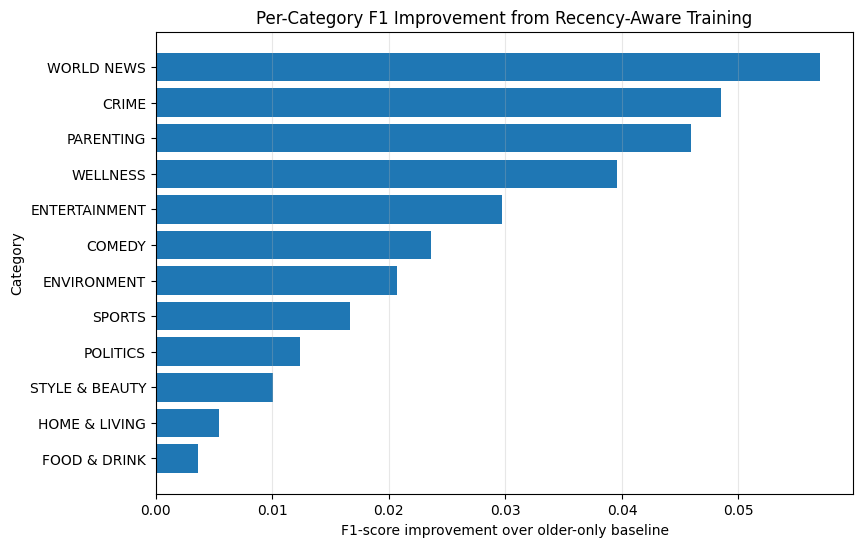

In [ ]:
# Creates graph for per-category F1 improvement

plot_data = category_error_analysis_display.sort_values(by='F1 Change', ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(plot_data['Category'], plot_data['F1 Change'])

plt.xlabel('F1-score improvement over older-only baseline')
plt.ylabel('Category')
plt.title('Per-Category F1 Improvement from Recency-Aware Training')
plt.grid(axis='x', alpha=0.3)

plt.savefig('hd_per_category_f1_improvement.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import files
files.download('hd_per_category_f1_improvement.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>